## Učitavanje biblioteka i podešavanje okruženja

In [9]:
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

from emotion_utils import (
    PAD_IDX,
    get_device,
    plot_history,
    prepare_emotion_data,
    print_evaluation,
    set_seed,
    train_model,
)

SEED = 7
set_seed(SEED)
device = get_device()
print(f'Device: {device}')

Device: cpu


## Učitavanje i priprema podataka

In [10]:
data = prepare_emotion_data(seed=SEED)

train_loader = data.train_loader
val_loader = data.val_loader
test_loader = data.test_loader
label_names = data.label_names

print(f'Trening:    {len(data.train_texts):>5} primera')
print(f'Validacija: {len(data.val_texts):>5} primera')
print(f'Test:       {len(data.test_texts):>5} primera')
print(f'Broj različitih tokena u trening skupu: {len(data.token_counts)}')
print(f'Veličina rečnika sa posebnim tokenima: {len(data.index_to_token)}')
print('Klase:', data.label_to_index)

example_ids = data.encode(data.train_texts[0])
example_inputs, example_lengths, _ = next(iter(train_loader))
print('Niz indeksa:', example_ids)
print('Oblik batch tenzora posle padding-a:', example_inputs.shape)
print('Dužine prvih pet sekvenci:', example_lengths[:5].tolist())

Trening:    15983 primera
Validacija:  1997 primera
Test:        2000 primera
Broj različitih tokena u trening skupu: 15202
Veličina rečnika sa posebnim tokenima: 7397
Klase: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
Niz indeksa: [2, 139, 3, 679]
Oblik batch tenzora posle padding-a: torch.Size([128, 46])
Dužine prvih pet sekvenci: [14, 16, 37, 13, 6]


## GRU model

In [12]:
class GRUClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_size,
        num_classes,
        padding_idx,
        num_layers=1,
        dropout=0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=padding_idx
        )
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        final_hidden = hidden[-1]
        return self.classifier(self.dropout(final_hidden))


model = GRUClassifier(
    vocab_size=len(data.index_to_token),
    embedding_dim=64,
    hidden_size=128,
    num_classes=len(label_names),
    padding_idx=PAD_IDX,
    num_layers=1,
    dropout=0.3,
).to(device)

print(model)

GRUClassifier(
  (embedding): Embedding(7397, 64, padding_idx=0)
  (gru): GRU(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=6, bias=True)
)


## Trening

In [13]:
EPOCHS = 10
LEARNING_RATE = 1e-3

history = train_model(
    model,
    train_loader,
    val_loader,
    device=device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
)

Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.5937, train acc: 0.3476 | val loss: 1.5346, val acc: 0.3921
Epoha 02 | train loss: 1.4478, train acc: 0.4382 | val loss: 1.3459, val acc: 0.4912
Epoha 03 | train loss: 1.0764, train acc: 0.6077 | val loss: 0.8803, val acc: 0.6905
Epoha 04 | train loss: 0.6220, train acc: 0.7789 | val loss: 0.5565, val acc: 0.8142
Epoha 05 | train loss: 0.3651, train acc: 0.8764 | val loss: 0.4163, val acc: 0.8633
Epoha 06 | train loss: 0.2360, train acc: 0.9165 | val loss: 0.3539, val acc: 0.8783
Epoha 07 | train loss: 0.1655, train acc: 0.9407 | val loss: 0.3253, val acc: 0.8958
Epoha 08 | train loss: 0.1231, train acc: 0.9535 | val loss: 0.3096, val acc: 0.9059
Epoha 09 | train loss: 0.0992, train acc: 0.9628 | val loss: 0.3062, val acc: 0.9014
Epoha 10 | train loss: 0.0788, train acc: 0.9698 | val loss: 0.3320, val acc: 0.9069


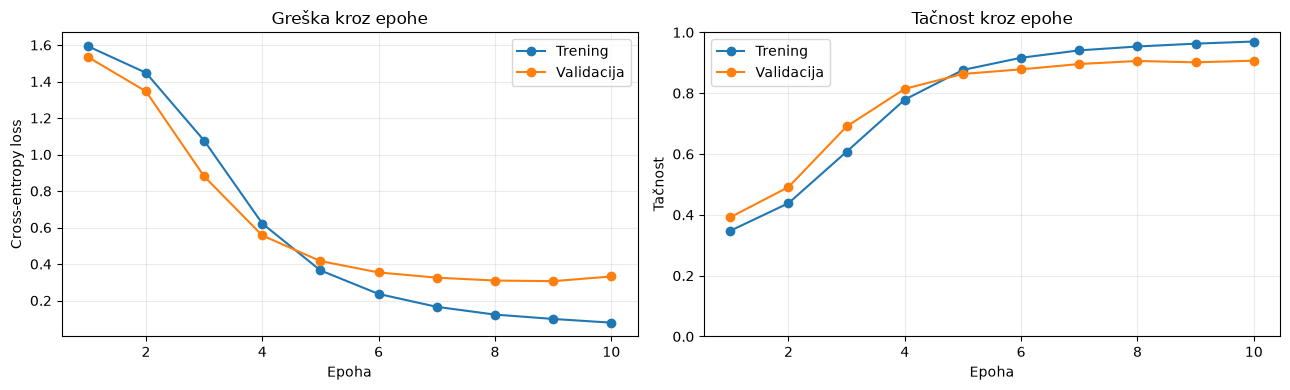

In [14]:
plot_history(history)

## Evaluacija modela

Evaluacija:   0%|          | 0/16 [00:00<?, ?it/s]

Test greška:  0.3137
Test tačnost: 0.8885

              precision    recall  f1-score   support

       anger     0.8582    0.8800    0.8689       275
        fear     0.8649    0.8571    0.8610       224
         joy     0.9142    0.9194    0.9168       695
        love     0.7186    0.7547    0.7362       159
     sadness     0.9557    0.9277    0.9415       581
    surprise     0.6818    0.6818    0.6818        66

    accuracy                         0.8885      2000
   macro avg     0.8322    0.8368    0.8344      2000
weighted avg     0.8898    0.8885    0.8890      2000



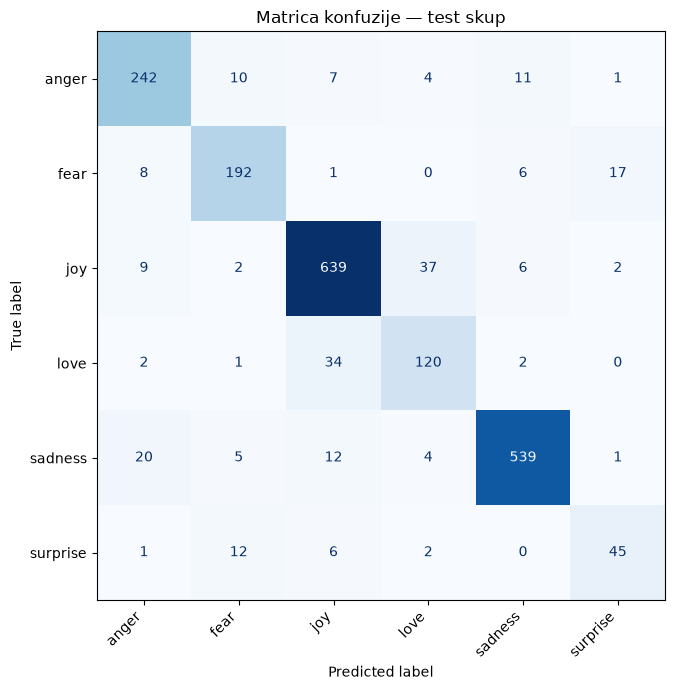

In [15]:
test_loss, test_accuracy, y_true, y_pred = print_evaluation(
    model, test_loader, label_names, device
)